In [3]:
import numpy as np
xf_train = np.load("processed-imgs/xf_train.npy")
xf_test = np.load("processed-imgs/xf_test.npy")
y_train = np.load("processed-imgs/y_train.npy")
y_test = np.load("processed-imgs/y_test.npy")
xi_train = np.load("processed-imgs/xi_train.npy")
xi_test = np.load("processed-imgs/xi_test.npy")
x_train_scaled = np.load("processed-imgs/x_train_scaled.npy")
x_test_scaled = np.load("processed-imgs/x_test_scaled.npy")
x_train_pca = np.load("processed-imgs/x_train_pca.npy")
x_test_pca = np.load("processed-imgs/x_test_pca.npy")   


In [4]:
x_test_pca.shape ,x_train_pca.shape

((2000, 115), (8000, 115))

In [5]:
x_test_pca

array([[ -1.7576433 ,   0.98067737,   2.0339165 , ...,   0.727061  ,
          0.75836504,  -0.07000392],
       [ 32.15146   ,   2.4785614 ,   5.3257594 , ...,   1.2402511 ,
          0.8401438 ,  -0.13040476],
       [-28.728977  ,  -4.549027  ,   2.2292933 , ...,   0.5742538 ,
         -0.6889132 ,   0.42501011],
       ...,
       [ 16.160866  ,   2.090489  ,  -4.3595243 , ...,  -1.7261423 ,
         -2.4322906 ,  -0.6946637 ],
       [ 21.45355   ,  -0.6279392 ,   3.009591  , ...,  -0.69054395,
         -0.51940715,  -0.3041634 ],
       [ -8.270946  ,   2.8719273 ,   7.212328  , ...,   0.5578771 ,
         -0.9436165 ,  -1.0005223 ]], dtype=float32)

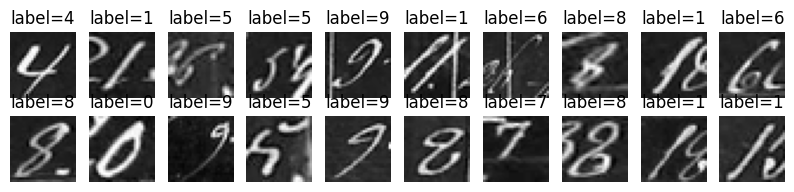

In [6]:
from plot_sample import plot_sample
plot_sample(xi_train, y_train)

#Multinomial

In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score , KFold , cross_validate
from time import time
log_reg_multi = LogisticRegression(max_iter=1000)



In [8]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)
start = time()
kf_scores=cross_validate(log_reg_multi, xf_train, y_train, cv=kf, scoring='accuracy',return_train_score=True
,verbose=5555)
time_log_multi_kf = time() - start
print(f"KFold Cross-validation train time: {time_log_multi_kf:.2f} seconds")
print(f"KFold Cross-validation train Accuracy scores: {kf_scores['train_score']}")
print(f"KFold Cross-validation test Accuracy scores: {kf_scores['test_score']}")

[CV] START .....................................................................
[CV] END ..................., score=(train=0.859, test=0.759) total time=   8.1s
[Parallel(n_jobs=1)]: Done   1 tasks      | elapsed:    8.1s
[CV] START .....................................................................
[CV] END ..................., score=(train=0.858, test=0.751) total time=  10.7s
[Parallel(n_jobs=1)]: Done   2 tasks      | elapsed:   19.0s
[CV] START .....................................................................
[CV] END ..................., score=(train=0.858, test=0.738) total time=   9.0s
[Parallel(n_jobs=1)]: Done   3 tasks      | elapsed:   28.1s
[CV] START .....................................................................
[CV] END ..................., score=(train=0.858, test=0.752) total time=   9.0s
[Parallel(n_jobs=1)]: Done   4 tasks      | elapsed:   37.2s
[CV] START .....................................................................
[CV] END ..................

In [9]:
avg_kf_score_log_multi_train = np.mean(kf_scores['train_score'])
print(f"Average KFold Cross-validation train Accuracy: {avg_kf_score_log_multi_train:.4f}")
std_kf_score_log_multi_train = np.std(kf_scores['train_score'])
print(f"Standard Deviation of KFold Cross-validation train Accuracy: {std_kf_score_log_multi_train:.4f}")

avg_kf_score_log_multi_test = np.mean(kf_scores['test_score'])
print(f"Average KFold Cross-validation test Accuracy: {avg_kf_score_log_multi_test:.4f}")
std_kf_score_log_multi_test = np.std(kf_scores['test_score'])
print(f"Standard Deviation of KFold Cross-validation  test Accuracy: {std_kf_score_log_multi_test:.4f}")

Average KFold Cross-validation train Accuracy: 0.8601
Standard Deviation of KFold Cross-validation train Accuracy: 0.0040
Average KFold Cross-validation test Accuracy: 0.7451
Standard Deviation of KFold Cross-validation  test Accuracy: 0.0122


In [10]:
start = time()
log_reg_multi.fit(xf_train, y_train)
time_log_multi_kf += time() - start

In [11]:
y_test_pred = log_reg_multi.predict(xf_test)
y_train_pred = log_reg_multi.predict(xf_train)
y_test_pred

array([9, 7, 3, ..., 2, 0, 9], dtype=int64)

In [93]:
sum(log_reg_multi.predict_proba(xf_test)[999])

1.0

In [12]:
print(f"Logistic Regression Multinomial Train Accuracy: {log_reg_multi.score(xf_train, y_train):.4f}")

print(f"Logistic Regression Multinomial Test Accuracy: {log_reg_multi.score(xf_test, y_test):.4f}")

Logistic Regression Multinomial Train Accuracy: 0.8521
Logistic Regression Multinomial Test Accuracy: 0.7480


In [13]:
from cmetrics import *
accuracy_log_multi = acc(y_test, y_test_pred)
print(f"Logistic Regression Multi Accuracy: {accuracy_log_multi:.4f}%")
prec_log_multi = precision(y_test, y_test_pred)
print(f"Logistic Regression Multi Precision: {prec_log_multi:.4f}%")
rec_log_multi = recall(y_test, y_test_pred)
print(f"Logistic Regression Multi Recall: {rec_log_multi:.4f}%")
f1_score_log_multi = f1(y_test, y_test_pred)
print(f"Logistic Regression Multi F1 Score: {f1_score_log_multi:.4f}%")

Logistic Regression Multi Accuracy: 74.8000%
Logistic Regression Multi Precision: 74.7916%
Logistic Regression Multi Recall: 74.8000%
Logistic Regression Multi F1 Score: 74.6586%


In [14]:
import json

metrics = {
    "accuracy": accuracy_log_multi,
    "precision": prec_log_multi,
    "recall": rec_log_multi,
    "f1_score": f1_score_log_multi,
    "train_time": time_log_multi_kf
}

with open("experiments/log_multi.json", "w") as f:
    json.dump(metrics, f, indent=4)


In [15]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

           0       0.75      0.79      0.77       200
           1       0.76      0.82      0.79       200
           2       0.76      0.73      0.75       200
           3       0.78      0.71      0.75       200
           4       0.73      0.72      0.73       200
           5       0.75      0.77      0.76       200
           6       0.79      0.84      0.82       200
           7       0.70      0.74      0.72       200
           8       0.72      0.58      0.64       200
           9       0.73      0.77      0.74       200

    accuracy                           0.75      2000
   macro avg       0.75      0.75      0.75      2000
weighted avg       0.75      0.75      0.75      2000



In [16]:
cm=conf_matrix(y_test, y_test_pred)
cm

array([[157,   9,   1,   1,   6,   6,  10,   2,   3,   5],
       [  6, 165,   4,   5,   0,   3,   0,  11,   4,   2],
       [  5,   8, 146,  11,   5,   5,   1,   8,   5,   6],
       [  6,   5,  13, 143,   7,   8,   0,   7,   3,   8],
       [  8,   5,   4,   3, 145,   5,   7,   5,   9,   9],
       [  8,   2,   4,   2,   3, 154,  17,   4,   6,   0],
       [  0,   8,   1,   0,   2,  15, 168,   0,   6,   0],
       [  1,   9,   8,   2,   4,   0,   1, 149,   7,  19],
       [  9,   5,   6,   7,  19,   9,   8,  12, 116,   9],
       [  9,   2,   4,   9,   8,   0,   0,  14,   1, 153]], dtype=int64)

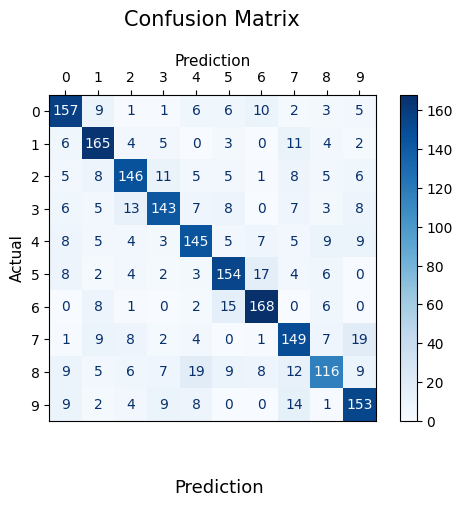

In [17]:
plot_confusion_matrix(cm)

What if we apply pca ?

In [18]:
log_reg_multi_pca = LogisticRegression(max_iter=1000)


In [19]:
start = time()
kf_scores_pca=cross_validate(log_reg_multi_pca, x_train_pca, y_train, cv=kf, scoring='accuracy',return_train_score=True
,verbose=5555)
time_log_multi_kf_pca = time() - start
print(f"KFold Cross-validation train time: {time_log_multi_kf_pca:.2f} seconds")
print(f"KFold Cross-validation train Accuracy scores: {kf_scores_pca['train_score']}")
print(f"KFold Cross-validation test Accuracy scores: {kf_scores_pca['test_score']}")


[CV] START .....................................................................
[CV] END ..................., score=(train=0.802, test=0.771) total time=   1.7s
[Parallel(n_jobs=1)]: Done   1 tasks      | elapsed:    1.8s
[CV] START .....................................................................
[CV] END ..................., score=(train=0.804, test=0.766) total time=   1.4s
[Parallel(n_jobs=1)]: Done   2 tasks      | elapsed:    3.3s
[CV] START .....................................................................
[CV] END ..................., score=(train=0.803, test=0.746) total time=   1.7s
[Parallel(n_jobs=1)]: Done   3 tasks      | elapsed:    5.1s
[CV] START .....................................................................
[CV] END ..................., score=(train=0.806, test=0.758) total time=   1.5s
[Parallel(n_jobs=1)]: Done   4 tasks      | elapsed:    6.7s
[CV] START .....................................................................
[CV] END ..................

In [20]:
avg_kf_score_log_multi_pca_train = np.mean(kf_scores_pca['train_score'])
print(f"Average KFold Cross-validation PCA train Accuracy: {avg_kf_score_log_multi_pca_train:.4f}")
std_kf_score_log_multi_pca_train = np.std(kf_scores_pca['train_score'])
print(f"Standard Deviation of KFold PCA Cross-validation train Accuracy: {std_kf_score_log_multi_pca_train:.4f}")

avg_kf_score_log_multi_pca_test = np.mean(kf_scores_pca['test_score'])
print(f"Average KFold Cross-validation PCA test Accuracy: {avg_kf_score_log_multi_pca_test:.4f}")
std_kf_score_log_multi_pca_test = np.std(kf_scores_pca['test_score'])
print(f"Standard Deviation of KFold Cross-validation PCA test Accuracy: {std_kf_score_log_multi_pca_test:.4f}")

Average KFold Cross-validation PCA train Accuracy: 0.8060
Standard Deviation of KFold PCA Cross-validation train Accuracy: 0.0049
Average KFold Cross-validation PCA test Accuracy: 0.7537
Standard Deviation of KFold Cross-validation PCA test Accuracy: 0.0151


In [21]:
start = time()
log_reg_multi_pca.fit(x_train_pca, y_train)
time_log_multi_kf_pca += time() - start

In [22]:
y_test_pred_pca = log_reg_multi_pca.predict(x_test_pca)
y_train_pred_pca = log_reg_multi_pca.predict(x_train_pca)
y_test_pred_pca

array([7, 7, 3, ..., 2, 0, 9], dtype=int64)

In [23]:
print(f"Logistic Regression Multinomial PCA Train Accuracy: {log_reg_multi_pca.score(x_train_pca, y_train):.4f}")

print(f"Logistic Regression Multinomial PCA Test Accuracy: {log_reg_multi_pca.score(x_test_pca, y_test):.4f}")

Logistic Regression Multinomial PCA Train Accuracy: 0.8037
Logistic Regression Multinomial PCA Test Accuracy: 0.7645


#✔ cross_val_score does NOT fit your model instance
#✔ It makes new cloned models internally using:
clone(log_reg)


#Each fold gets a fresh model, trained only inside cross-validation.

 log_reg_pca instance remains unfitted, so after checks our model generlizain , do:
 log_reg_pca.fit(x_tain_pca , y_train)

In [24]:
from sklearn.model_selection import StratifiedKFold
from sklearn.multiclass import OneVsRestClassifier

In [67]:

log_reg_pca=OneVsRestClassifier(LogisticRegression(max_iter=1000 , solver='liblinear'))
skf=StratifiedKFold(n_splits=5 , shuffle=True , random_state=42)
start = time()
skf_scores_pca=cross_val_score(log_reg_pca, x_train_pca, y_train, cv=skf, scoring='accuracy')
time_log_skf_pca = time() - start
print(f"KFold Cross-validation time: {time_log_skf_pca:.2f} seconds")
print(f"KFold Cross-validation Accuracy scores: {skf_scores_pca}")


KFold Cross-validation time: 17.36 seconds
KFold Cross-validation Accuracy scores: [0.748125 0.75375  0.764375 0.75125  0.74375 ]


In [68]:
log_reg_pca.fit(x_train_pca, y_train)


,estimator,LogisticRegre...r='liblinear')
,n_jobs,None
,verbose,0
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None


In [69]:
avg_skf_score_log_pca = np.mean(skf_scores_pca)
print(f"Average KFold Cross-validation Accuracy: {avg_skf_score_log_pca:.4f}")
std_skf_score_log_pca = np.std(skf_scores_pca)
print(f"Standard Deviation of KFold Cross-validation Accuracy: {std_skf_score_log_pca:.4f}")

Average KFold Cross-validation Accuracy: 0.7522
Standard Deviation of KFold Cross-validation Accuracy: 0.0069


In [70]:
y_test_pred_pca = log_reg_pca.predict(x_test_pca)
y_train_pred_pca = log_reg_pca.predict(x_train_pca)
y_test_pred_pca

array([7, 7, 3, ..., 2, 2, 9], dtype=int64)

In [72]:
print(f"Logistic Regression PCA Train Accuracy: {log_reg_pca.score(x_train_pca, y_train):.4f}")

print(f"Logistic Regression PCA Test Accuracy: {log_reg_pca.score(x_test_pca, y_test):.4f}")

Logistic Regression PCA Train Accuracy: 0.7906
Logistic Regression PCA Test Accuracy: 0.7645


In [73]:
accuracy_log_pca = acc(y_test, y_test_pred_pca)
print(f"Logistic Regression PCA Accuracy: {accuracy_log_pca:.4f}%")
prec_log_pca = precision(y_test, y_test_pred_pca)
print(f"Logistic Regression PCA Precision: {prec_log_pca:.4f}%")
rec_log_pca = recall(y_test, y_test_pred_pca)
print(f"Logistic Regression PCA Recall: {rec_log_pca:.4f}%")
f1_score_log_pca = f1(y_test, y_test_pred_pca)
print(f"Logistic Regression PCA F1 Score: {f1_score_log_pca:.4f}%")

Logistic Regression PCA Accuracy: 76.4500%
Logistic Regression PCA Precision: 76.4414%
Logistic Regression PCA Recall: 76.4500%
Logistic Regression PCA F1 Score: 76.3759%


In [75]:
import json

metrics = {
    "accuracy": accuracy_log_pca,
    "precision": prec_log_pca,
    "recall": rec_log_pca,
    "f1_score": f1_score_log_pca,
    "train_time": time_log_skf_pca
}

with open("experiments/log_pca.json", "w") as f:
    json.dump(metrics, f, indent=4)


In [76]:
from sklearn.metrics import classification_report
print(classification_report(y_test , y_test_pred_pca))

              precision    recall  f1-score   support

           0       0.77      0.81      0.79       200
           1       0.76      0.80      0.78       200
           2       0.82      0.75      0.78       200
           3       0.83      0.79      0.81       200
           4       0.76      0.77      0.76       200
           5       0.77      0.74      0.76       200
           6       0.79      0.88      0.83       200
           7       0.71      0.71      0.71       200
           8       0.70      0.64      0.67       200
           9       0.74      0.76      0.75       200

    accuracy                           0.76      2000
   macro avg       0.76      0.76      0.76      2000
weighted avg       0.76      0.76      0.76      2000



In [77]:
cm =conf_matrix(y_test , y_test_pred_pca)
cm

array([[163,   7,   1,   2,   4,   3,   8,   4,   4,   4],
       [  6, 159,   4,   5,   1,   3,   3,  11,   8,   0],
       [  3,   6, 150,   8,   5,   3,   2,   8,   4,  11],
       [  9,   3,   6, 157,   8,   3,   0,   4,   7,   3],
       [  5,   8,   3,   2, 154,   2,   8,   6,   6,   6],
       [  6,   4,   3,   3,   2, 149,  18,   5,   9,   1],
       [  0,   7,   0,   0,   2,  11, 176,   0,   4,   0],
       [  4,   8,   7,   1,   4,   2,   2, 142,   7,  23],
       [  9,   5,   5,   6,  12,  16,   5,   9, 128,   5],
       [  6,   3,   5,   6,  11,   2,   0,  11,   5, 151]], dtype=int64)

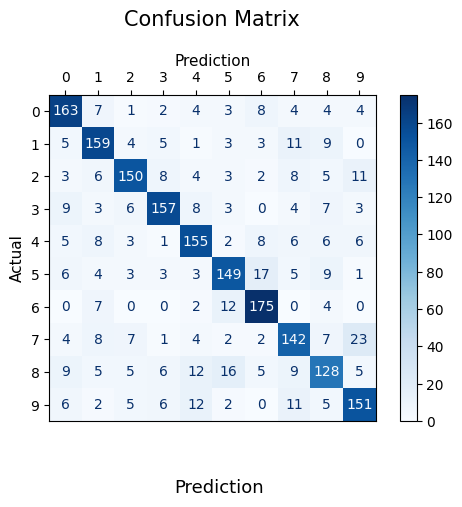

In [34]:
plot_confusion_matrix(cm)

In [122]:
y_prop_pca = log_reg_pca.predict_proba(x_test_pca)[0]
sum(y_prop_pca)


1.0

In [101]:
log_bi = LogisticRegression(max_iter=1000, multi_class='ovr',solver='lbfgs')
log_bi.fit(x_train_scaled , y_train)

c:\Users\sh2\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1281: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\sh2\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'liblinear'
,max_iter,1000
,multi_class,'ovr'


In [126]:
y_prop_bi = log_bi.predict_proba(x_test_scaled)[0]
print(y_prop_bi)
print(np.argmax (y_prop_bi))
print(sum(y_prop_bi))

[4.94862353e-05 2.13816544e-02 8.96480632e-04 1.74613733e-02
 1.22681216e-02 2.63679459e-03 1.32170474e-03 3.18288187e-02
 4.41933927e-01 4.70221638e-01]
9
1.0


In [110]:
from scipy.special import expit
help(log_bi)

Help on LogisticRegression in module sklearn.linear_model._logistic object:

class LogisticRegression(sklearn.linear_model._base.LinearClassifierMixin, sklearn.linear_model._base.SparseCoefMixin, sklearn.base.BaseEstimator)
 |  LogisticRegression(penalty='l2', *, dual=False, tol=0.0001, C=1.0, fit_intercept=True, intercept_scaling=1, class_weight=None, random_state=None, solver='lbfgs', max_iter=100, multi_class='deprecated', verbose=0, warm_start=False, n_jobs=None, l1_ratio=None)
 |
 |  Logistic Regression (aka logit, MaxEnt) classifier.
 |
 |  This class implements regularized logistic regression using the
 |  'liblinear' library, 'newton-cg', 'sag', 'saga' and 'lbfgs' solvers. **Note
 |  that regularization is applied by default**. It can handle both dense
 |  and sparse input. Use C-ordered arrays or CSR matrices containing 64-bit
 |  floats for optimal performance; any other input format will be converted
 |  (and copied).
 |
 |  The 'newton-cg', 'sag', and 'lbfgs' solvers suppor

In [112]:
z_score = log_bi.decision_function(x_test_scaled)
z_score

array([[-11.07380037,  -4.99849646,  -8.17675268, ...,  -4.59735502,
         -1.82746789,  -1.75507684],
       [ -1.78055573,  -7.57923146,  -7.97283783, ...,   0.93962327,
         -3.96975973,  -7.13766644],
       [ -4.0426268 , -10.44227003,  -4.63531733, ...,  -6.14239072,
         -6.55406604, -13.78627789],
       ...,
       [ -5.9916361 ,  -7.84561216,   8.81989378, ..., -11.75260729,
         -7.67286647, -11.16973039],
       [ -1.80149169,  -9.70022816,  -2.24010875, ...,  -3.92934483,
         -6.81449344,  -4.18935199],
       [ -8.40921733,  -5.02463755,  -4.71298409, ...,  -1.975037  ,
          3.0290772 ,   8.75609611]])

In [129]:
prob = expit(z_score)
print(prob[0])
print(sum(prob[0]))
print(np.argmax(prob[0]))

[1.55132528e-05 6.70285398e-03 2.81034323e-04 5.47389989e-03
 3.84588704e-03 8.26598766e-04 4.14336220e-04 9.97789601e-03
 1.38540196e-01 1.47408003e-01]
0.31348621864050397
9


1.6674939878667143